# DSA2050 Week 1: Retail Analysis

**Student Name:** Mark Mayana

**Student ID:** 669482

**Objective:** Analyse a retail dataset and produce a reproducible notebook with KPIs and visualisations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

Fontconfig error: Cannot load default config file: No such file: (null)


In [ ]:
df = pd.read_csv("/DSA_2050_Week1_Retail_Data.csv")

In [5]:
df.head()
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   OrderID        300 non-null    str  
 1   Date           300 non-null    str  
 2   CustomerID     300 non-null    str  
 3   Region         300 non-null    str  
 4   Channel        300 non-null    str  
 5   Category       300 non-null    str  
 6   Product        300 non-null    str  
 7   Quantity       300 non-null    int64
 8   UnitPrice_KES  300 non-null    int64
 9   Revenue_KES    300 non-null    int64
 10  PaymentMethod  300 non-null    str  
dtypes: int64(3), str(8)
memory usage: 45.2 KB


**Dataset explanation**

- Number of rows: 300
- Number of columns: 11
- Main data types:
  - Object/text: OrderID, Date, CustomerID, Region, Channel, Category, Product, PaymentMethod
  - Integer: Quantity, UnitPrice_KES, Revenue_KES
- What one row represents: One row represents **one retail order/transaction** for a single product. It includes the order ID, customer, region, sales channel, product category, product name, quantity, unit price, revenue, and payment method.

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

print("Missing values:")
print(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
OrderID          0
Date             0
CustomerID       0
Region           0
Channel          0
Category         0
Product          0
Quantity         0
UnitPrice_KES    0
Revenue_KES      0
PaymentMethod    0
dtype: int64

Duplicate rows:
0


In [7]:
total_revenue = df['Revenue_KES'].sum()
num_transactions = df['OrderID'].nunique()
avg_transaction_value = total_revenue / num_transactions

print(f"KPI 1 - Total Revenue (KES): {total_revenue:,.2f}")
print(f"KPI 2 - Number of Transactions: {num_transactions}")
print(f"KPI 3 - Average Transaction Value (KES): {avg_transaction_value:,.2f}")

KPI 1 - Total Revenue (KES): 3,206,450.00
KPI 2 - Number of Transactions: 300
KPI 3 - Average Transaction Value (KES): 10,688.17


**KPI 1 — Total Revenue:** The overall revenue generated from all orders in the dataset.  
**KPI 2 — Number of Transactions:** The number of unique orders placed.  
**KPI 3 — Average Transaction Value:** The average revenue earned per order.  

These KPIs help the retail manager understand overall sales performance, order volume, and average customer spend.

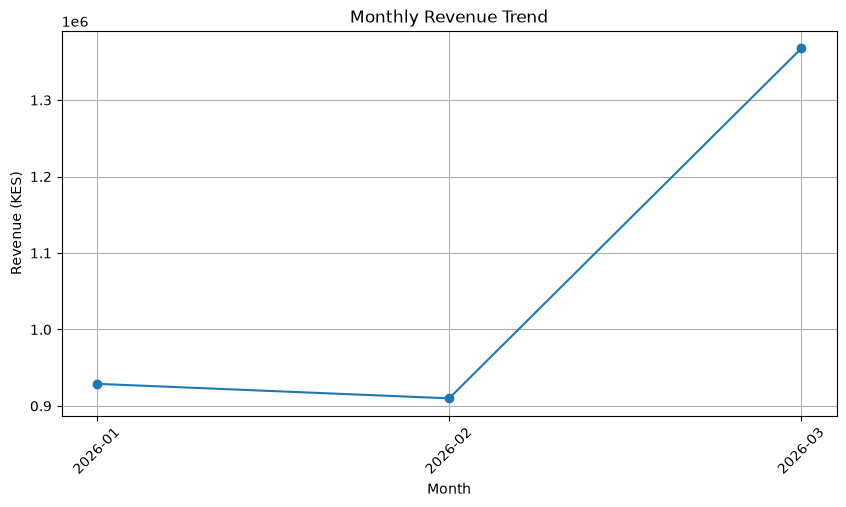

In [8]:
monthly_revenue = df.groupby(df['Date'].dt.to_period('M'))['Revenue_KES'].sum()
monthly_revenue.index = monthly_revenue.index.astype(str)

plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (KES)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**Interpretation:** Revenue varies across the months covered by the dataset. The plot shows which month had the highest and lowest sales, helping the business identify seasonal patterns or months that need more promotion.

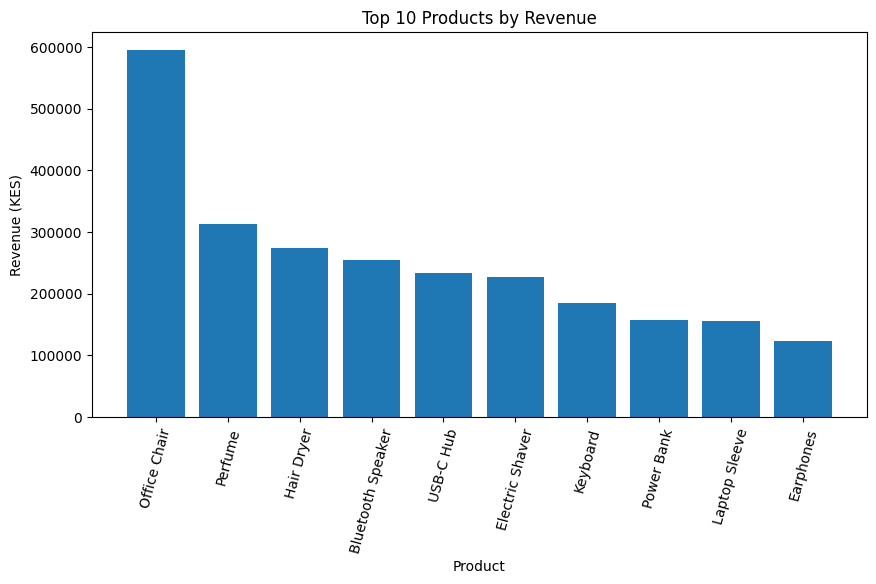

In [ ]:
top_products = df.groupby('Product')['Revenue_KES'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_products.index, top_products.values)
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue (KES)')
plt.xticks(rotation=75)
plt.show()

**Interpretation:** A small number of products generate a large share of total revenue. These top-performing products should be prioritised for stock availability and marketing attention.

## Conclusion

This analysis used a retail dataset to calculate three KPIs: Total Revenue, Number of Transactions, and Average Transaction Value. Two visualisations showed monthly revenue trends and the top 10 products by revenue. The findings suggest that revenue is concentrated in certain products and varies by month. The analysis supports decisions about which products to promote and when to run sales campaigns.

**Limitation:** The dataset does not include cost or profit information, so we cannot conclude whether high-revenue products are actually profitable. It also only covers a limited time period and does not include returns or marketing spend.

## Decision Brief

| Section | Details |
|---|---|
| **Business problem** | Understanding which products and months drive retail revenue. |
| **Stakeholder** | Retail manager / sales director. |
| **Decision** | Which products to prioritise for stock and promotion, and when to run sales campaigns. |
|**Task Type: Descriptive**| it summarises what happened, rather than predicting future outcomes.|
| **Unit of analysis** | One row represents one retail order/transaction. |
| **Three KPIs** | Total Revenue, Number of Transactions, Average Transaction Value. |
| **Initial findings** | Revenue is concentrated in a few top products. Monthly revenue fluctuates, showing possible seasonal demand. |
| **Limitation** | No cost/profit data, no returns, and limited time period, so profitability cannot be assessed. |